In [22]:
import numpy as np
import tqdm
import os
import re
import ipywidgets
import matplotlib.pyplot as plt
from scipy.constants import k, e
from scipy.interpolate import RegularGridInterpolator
import sys
sys.path.append('../../sedov_theory/python/')
from sedov_theory import SedovTalorProblem
import yt
from analysis_tool import CastroSimulation

In [23]:
run_dir = '../run/'
file_start = 'plt_1d_'

In [24]:
cs = CastroSimulation(run_dir, file_start)

100%|█████████████████████████████████████████| 389/389 [00:04<00:00, 83.79it/s]


# Compare data with theory

In [25]:
# Calculate analytical solution
gamma = 5./3
rho = 3.24e-6 # g / cm^3
E = 90 # erg / cm

sol = SedovTalorProblem(gamma, E, rho)

In [26]:
import skimage
import matplotlib.pyplot as plt

In [27]:
def plot(filename, offset = 0.455):

    time = float(re.findall('hydrotime([\d\.]+)', filename)[0])*1e-9
    data = skimage.io.imread(filename)
    r, q, t = cs.extract_data( time, 'density', level=3)
    
    x = 9.9*np.arange(data.shape[1])
    plt.plot( x-offset*1e3, data[16]*1.e17, '-o', label='Experiments' )
    plt.plot( r*1e4, q*1e18/1.67e-6, 'k-', label='Simulation' )
    plt.plot( -r*1e4, q*1e18/1.67e-6, 'k-' )
    plt.grid()
    plt.legend(loc=0)
    plt.ylabel('Density (cm$^{-3}$)')
    plt.xlabel('Position ($\mu$m)')
    plt.xlim(-150, 150)
    plt.ylim(0, 10e18)
    plt.title('t = %.1f ns' %(time*1.e9))

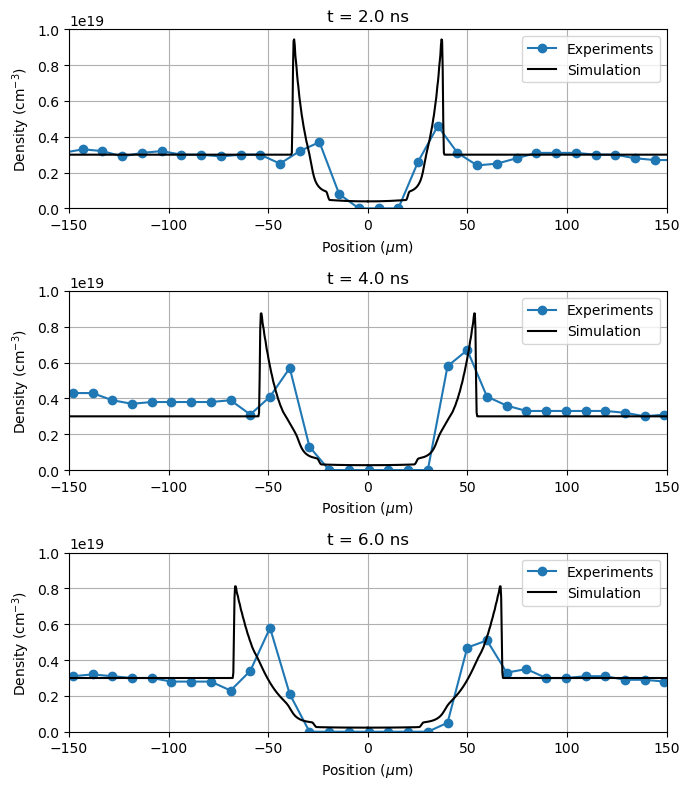

In [28]:
plt.figure(figsize=(7, 8))

plt.subplot(311)
plot('/Users/rlehe/Downloads/HTT_nepng/Scan027_HTT_nex1e17png_045hydrotime2.0ns.png', offset=0.45)

plt.subplot(312)
plot('/Users/rlehe/Downloads/HTT_nepng/Scan027_HTT_nex1e17png_076hydrotime4.0ns.png')

plt.subplot(313)
plot('/Users/rlehe/Downloads/HTT_nepng/Scan027_HTT_nex1e17png_105hydrotime6.0ns.png')

plt.tight_layout()
plt.savefig('Evolution.png')

In [36]:
def plot(i):

    for filename in os.listdir('/Users/rlehe/Downloads/HTT_nepng/'):
        if filename.startswith('Scan027_HTT_nex1e17png_%03d' %i):
            break
    time = float(re.findall('hydrotime-*([\d\.]+)', filename)[0])*1e-9
    data = skimage.io.imread('/Users/rlehe/Downloads/HTT_nepng/' + filename)
    extent = [-9.9*data.shape[1]/2, 9.9*data.shape[1]/2, -9.9*data.shape[0]/2, 9.9*data.shape[0]/2]
    plt.imshow( data*1e17, extent=extent, vmax=5e18 )
    plt.colorbar()
    plt.title('t = %.2f ns' %(time*1.e9))

20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110


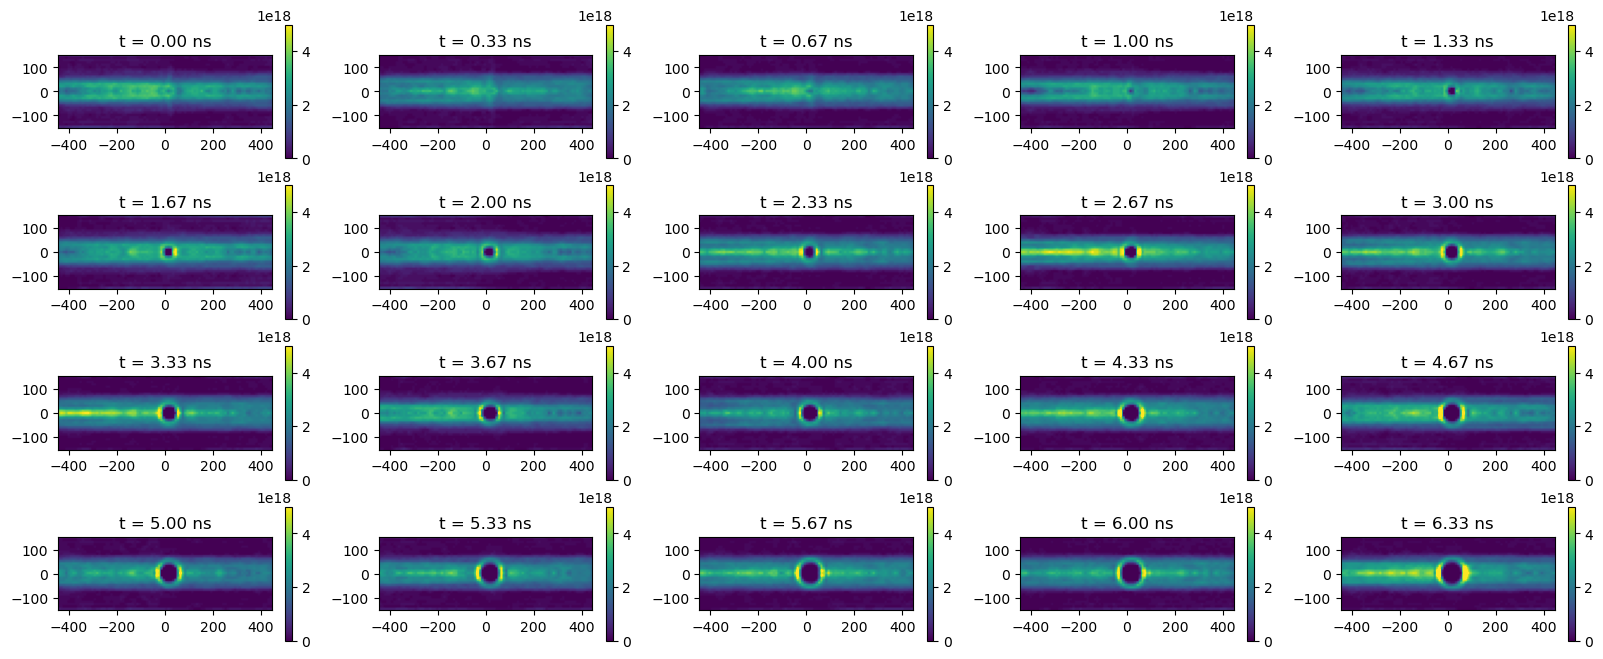

In [63]:
plt.figure(figsize=(20,8))

plt.subplot(4,5,1)
plot(16)

for i in range(19):

    plt.subplot(4,5,2+i)
    print(20+i*5)
    plot(20+i*5)

plt.savefig('Densities.png')
